<a href="https://colab.research.google.com/github/manasvik2006/CodSoft/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install any missing libraries (most are pre-installed in Colab)
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud nltk

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.multiclass import OneVsRestClassifier

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
from google.colab import files

print("📁 Please upload your train_data.txt and test_data.txt files:")
uploaded = files.upload()

📁 Please upload your train_data.txt and test_data.txt files:


Saving train_data.txt to train_data.txt
Saving test_data.txt to test_data.txt


In [ ]:
def parse_train_data(filepath):
    """
    Train format: ID ::: Title ::: Genre ::: Plot
    """
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(' ::: ')
            if len(parts) >= 4:
                records.append({
                    'id': parts[0].strip(),
                    'title': parts[1].strip(),
                    'genre': parts[2].strip(),
                    'plot': parts[3].strip()
                })
    return pd.DataFrame(records)


def parse_test_data(filepath):
    """
    Test format: ID ::: Title ::: Plot  (no genre column)
    """
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(' ::: ')
            if len(parts) >= 3:
                records.append({
                    'id': parts[0].strip(),
                    'title': parts[1].strip(),
                    'plot': parts[2].strip()
                })
    return pd.DataFrame(records)


train_df = parse_train_data('train_data.txt')
test_df  = parse_test_data('test_data.txt')

print(f"✅ Train samples : {len(train_df):,}")
print(f"✅ Test  samples : {len(test_df):,}")
train_df.head(3)

✅ Train samples : 54,214
✅ Test  samples : 54,200


,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...


In [ ]:
print("📊 Genre Distribution (Top 20)")
genre_counts = train_df['genre'].value_counts()
print(genre_counts.head(20).to_string())
print(f"\nTotal unique genres: {train_df['genre'].nunique()}")

📊 Genre Distribution (Top 20)
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323

Total unique genres: 27


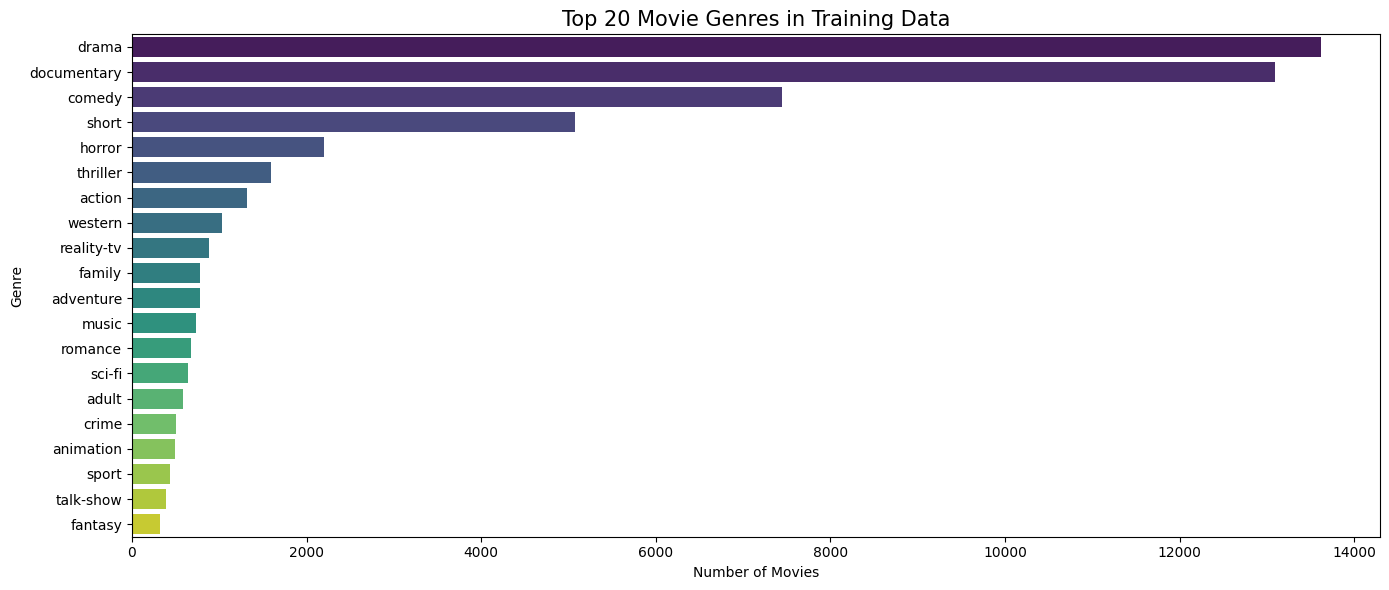

In [ ]:
plt.figure(figsize=(14, 6))
top_genres = genre_counts.head(20)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 20 Movie Genres in Training Data', fontsize=15)
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

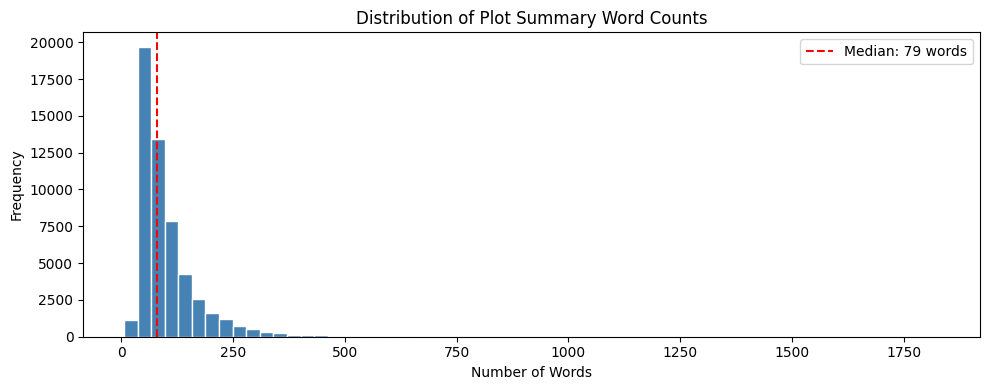

In [ ]:
# Plot length distribution
train_df['plot_length'] = train_df['plot'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 4))
plt.hist(train_df['plot_length'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Plot Summary Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(train_df['plot_length'].median(), color='red', linestyle='--',
            label=f'Median: {train_df["plot_length"].median():.0f} words')
plt.legend()
plt.tight_layout()
plt.show()

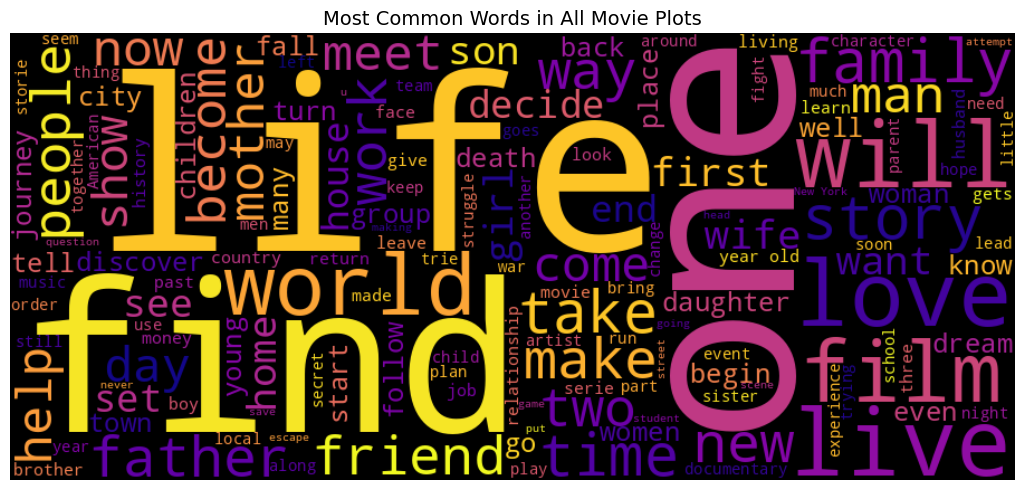

In [ ]:
# WordCloud for most frequent genres combined
all_plots = ' '.join(train_df['plot'].tolist())
wc = WordCloud(width=900, height=400, background_color='black',
               colormap='plasma', max_words=150).generate(all_plots)
plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in All Movie Plots', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("🔄 Cleaning text... (this may take ~1–2 min for large datasets)")
train_df['clean_plot'] = train_df['plot'].apply(clean_text)
test_df['clean_plot']  = test_df['plot'].apply(clean_text)
print("✅ Text cleaning complete!")
print("\nExample — Original:")
print(train_df['plot'].iloc[0][:200])
print("\nExample — Cleaned:")
print(train_df['clean_plot'].iloc[0][:200])

🔄 Cleaning text... (this may take ~1–2 min for large datasets)
✅ Text cleaning complete!

Example — Original:
Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone

Example — Cleaned:
listening conversation doctor parent year old oscar learns nobody courage tell week live furious refuse speak anyone except straight talking rose lady pink meet hospital stair christmas approach rose 


In [ ]:
# Keep only genres with at least 50 training examples for reliable learning
MIN_SAMPLES = 50
genre_freq = train_df['genre'].value_counts()
valid_genres = genre_freq[genre_freq >= MIN_SAMPLES].index
train_filtered = train_df[train_df['genre'].isin(valid_genres)].copy()

print(f"Genres kept  : {len(valid_genres)} (>= {MIN_SAMPLES} samples each)")
print(f"Rows kept    : {len(train_filtered):,} / {len(train_df):,}")

le = LabelEncoder()
train_filtered['label'] = le.fit_transform(train_filtered['genre'])
NUM_CLASSES = len(le.classes_)
print(f"\nGenre classes: {list(le.classes_)}")

Genres kept  : 27 (>= 50 samples each)
Rows kept    : 54,214 / 54,214

Genre classes: ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


In [ ]:
# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,     # apply log normalization
    min_df=3
)

X = tfidf.fit_transform(train_filtered['clean_plot'])
y = train_filtered['label'].values
X_test_final = tfidf.transform(test_df['clean_plot'])

print(f"TF-IDF matrix shape (train) : {X.shape}")
print(f"TF-IDF matrix shape (test)  : {X_test_final.shape}")

TF-IDF matrix shape (train) : (54214, 50000)
TF-IDF matrix shape (test)  : (54200, 50000)


In [ ]:
# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
print(f"Training size   : {X_train.shape[0]:,}")
print(f"Validation size : {X_val.shape[0]:,}")

Training size   : 46,081
Validation size : 8,133


In [ ]:
models = {
    'Naive Bayes (MultinomialNB)': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        C=5, max_iter=1000, solver='saga', random_state=42
    ),
    'Linear SVM (LinearSVC)': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print('='*55)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc
    trained_models[name] = model
    print(f"  Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print()
    print(classification_report(y_val, y_pred,
                                target_names=le.classes_,
                                zero_division=0))

print("\n✅ All models trained!")


  Training: Naive Bayes (MultinomialNB)
  Validation Accuracy: 0.5566 (55.66%)

              precision    recall  f1-score   support

      action       0.61      0.22      0.32       197
       adult       0.65      0.17      0.27        88
   adventure       0.60      0.10      0.18       116
   animation       0.00      0.00      0.00        75
   biography       0.00      0.00      0.00        40
      comedy       0.52      0.52      0.52      1117
       crime       0.00      0.00      0.00        76
 documentary       0.60      0.87      0.71      1965
       drama       0.50      0.80      0.62      2042
      family       1.00      0.04      0.08       117
     fantasy       0.00      0.00      0.00        48
   game-show       1.00      0.38      0.55        29
     history       0.00      0.00      0.00        36
      horror       0.70      0.53      0.60       331
       music       0.72      0.28      0.41       110
     musical       0.00      0.00      0.00        41


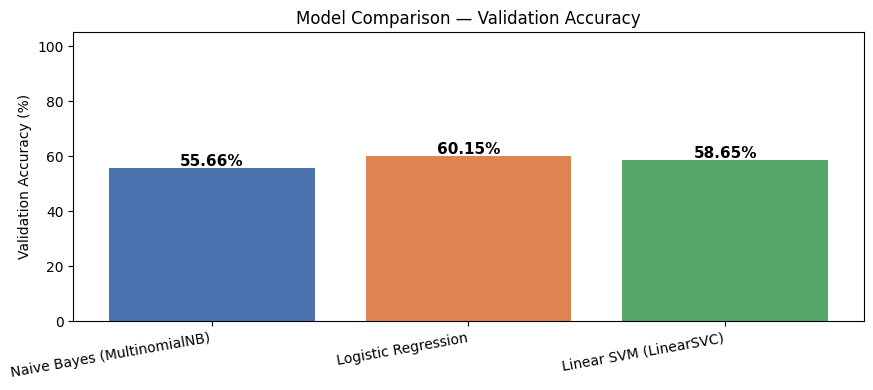

In [ ]:
plt.figure(figsize=(9, 4))
names = list(results.keys())
accs  = [results[n] * 100 for n in names]
bars  = plt.bar(names, accs, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylim(0, 105)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison — Validation Accuracy')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

🏆 Best Model: Logistic Regression  (60.15%)


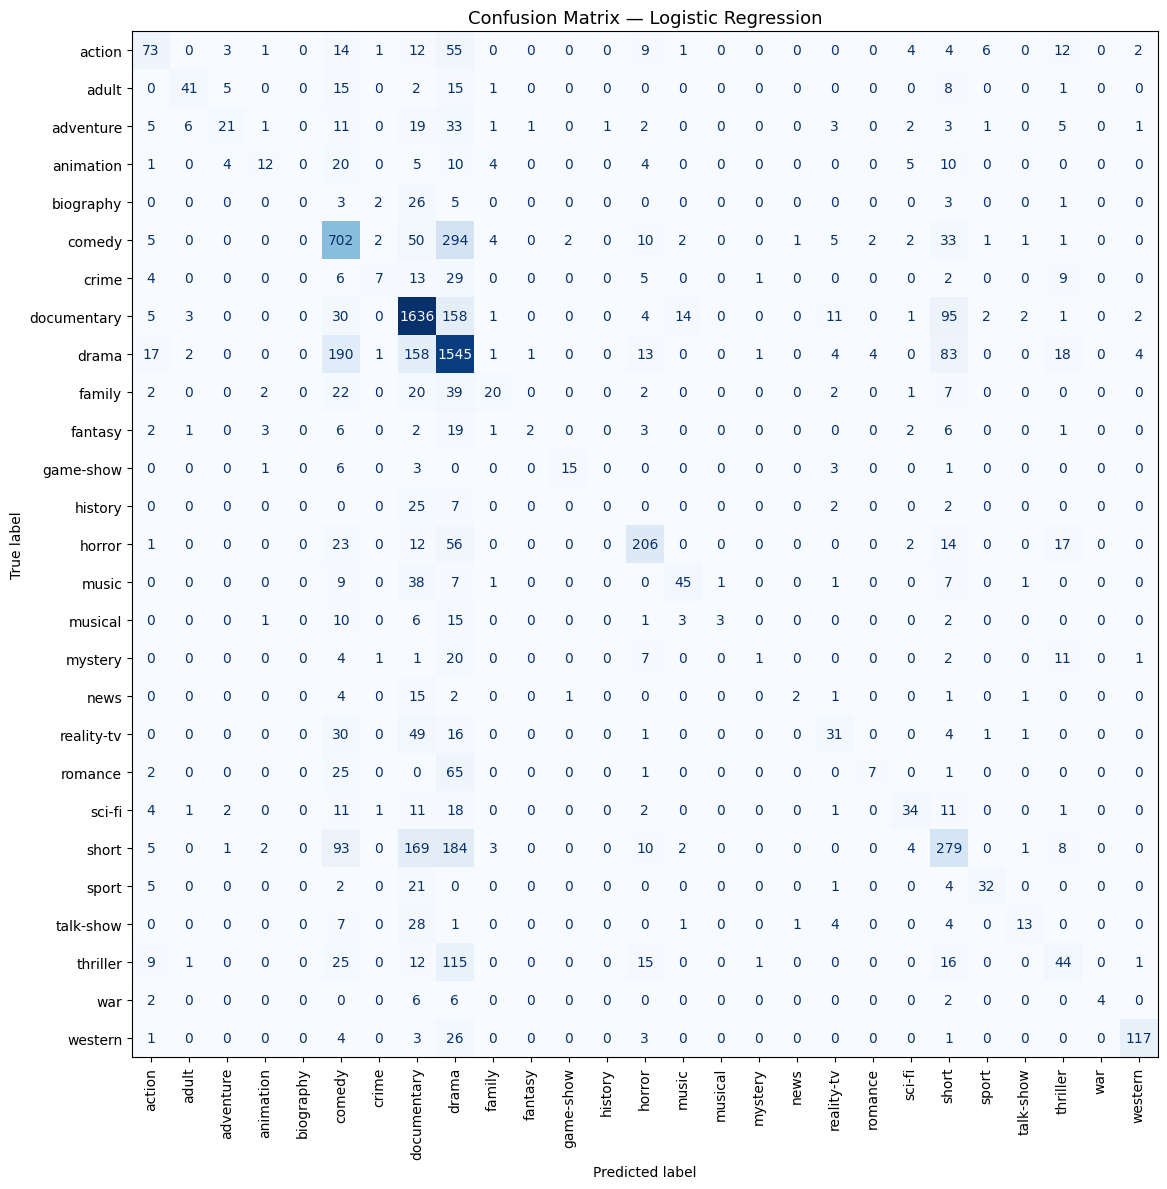

In [ ]:
best_model_name = max(results, key=results.get)
best_model      = trained_models[best_model_name]
print(f"🏆 Best Model: {best_model_name}  ({results[best_model_name]*100:.2f}%)")

y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_best)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Use best model to predict genres for the test set
test_predictions = best_model.predict(X_test_final)
test_df['predicted_genre'] = le.inverse_transform(test_predictions)

submission = test_df[['id', 'title', 'predicted_genre']]
submission.columns = ['ID', 'Title', 'Predicted_Genre']
submission.to_csv('predictions.csv', index=False)

print("📄 Sample Predictions:")
print(submission.head(10).to_string(index=False))

from google.colab import files
files.download('predictions.csv')
print("\n✅ predictions.csv downloaded!")

📄 Sample Predictions:
ID                                      Title Predicted_Genre
 1                       Edgar's Lunch (1998)          comedy
 2                   La guerra de papá (1977)           drama
 3                Off the Beaten Track (2010)     documentary
 4                     Meu Amigo Hindu (2015)           drama
 5                          Er nu zhai (1955)           drama
 6                         Riddle Room (2016)           drama
 7                             L'amica (1969)           drama
 8                       Ina Mina Dika (1989)          comedy
 9 Equinox Special: Britain's Tornados (2005)     documentary
10                               Press (2011)           drama


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ predictions.csv downloaded!
